In [39]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [40]:
df=pd.read_csv('decision_tree_dataset.csv')
df

,Age,Salary,Experience,Education_Level,City,Purchased
0,56,81272,9,Master,Houston,1
1,46,112152,9,Bachelor,Houston,1
2,32,87649,12,High School,New York,1
3,60,84674,36,Bachelor,Houston,1
4,25,33760,37,Bachelor,Phoenix,0
...,...,...,...,...,...,...
1995,42,100098,17,PhD,Chicago,1
1996,37,93016,25,Master,Los Angeles,1
1997,19,46672,6,PhD,Chicago,0
1998,56,24213,0,PhD,Phoenix,0


In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Age              2000 non-null   int64 
 1   Salary           2000 non-null   int64 
 2   Experience       2000 non-null   int64 
 3   Education_Level  2000 non-null   object
 4   City             2000 non-null   object
 5   Purchased        2000 non-null   int64 
dtypes: int64(4), object(2)
memory usage: 93.9+ KB


In [42]:
df.describe()

,Age,Salary,Experience,Purchased
count,2000.00000,2000.000000,2000.000000,2000.000000
mean,41.31650,69483.955000,19.553000,0.585000
std,13.46566,28956.311913,11.405755,0.492845
min,18.00000,20138.000000,0.000000,0.000000
25%,30.00000,43905.250000,10.000000,0.000000
50%,42.00000,69672.000000,19.000000,1.000000
75%,53.00000,94671.250000,29.000000,1.000000
max,64.00000,119983.000000,39.000000,1.000000


In [43]:
df.columns

Index(['Age', 'Salary', 'Experience', 'Education_Level', 'City', 'Purchased'], dtype='object')

In [44]:
df.duplicated().sum()

np.int64(0)

In [45]:
for i in df.select_dtypes('object'):
    print(df[i].unique())

['Master' 'Bachelor' 'High School' 'PhD']
['Houston' 'New York' 'Phoenix' 'Los Angeles' 'Chicago']


<Axes: >

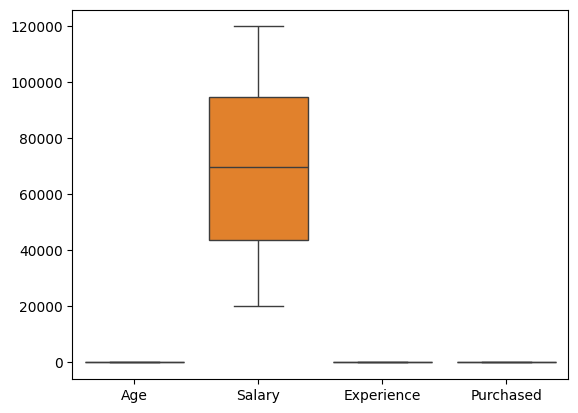

In [46]:
sns.boxplot(df)

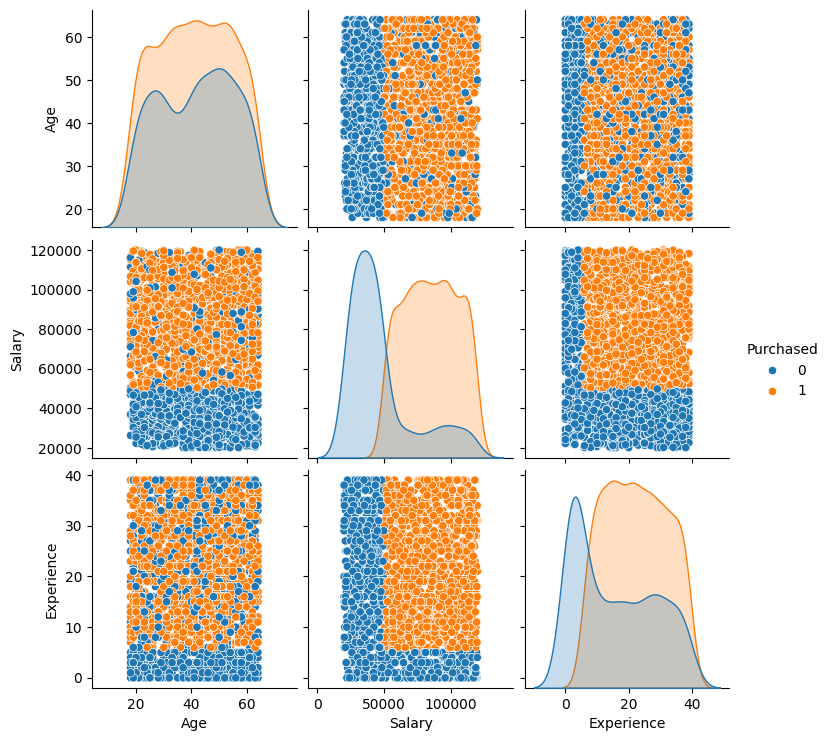

In [47]:
sns.pairplot(df,
             vars=['Age', 'Salary', 'Experience'],
             hue= 'Purchased')

In [48]:
x=df.drop('Purchased',axis=1)
y=df[['Purchased']]
x

,Age,Salary,Experience,Education_Level,City
0,56,81272,9,Master,Houston
1,46,112152,9,Bachelor,Houston
2,32,87649,12,High School,New York
3,60,84674,36,Bachelor,Houston
4,25,33760,37,Bachelor,Phoenix
...,...,...,...,...,...
1995,42,100098,17,PhD,Chicago
1996,37,93016,25,Master,Los Angeles
1997,19,46672,6,PhD,Chicago
1998,56,24213,0,PhD,Phoenix


In [49]:
y

,Purchased
0,1
1,1
2,1
3,1
4,0
...,...
1995,1
1996,1
1997,0
1998,0


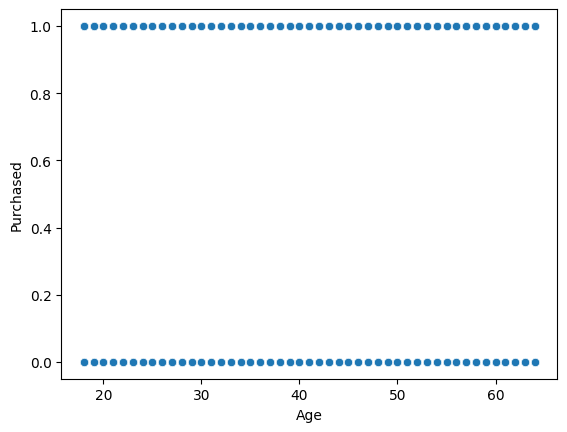

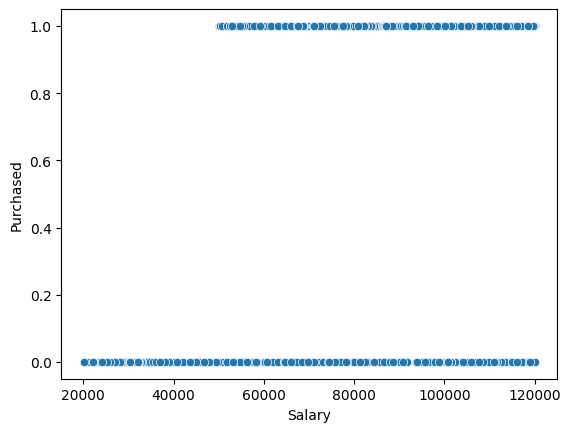

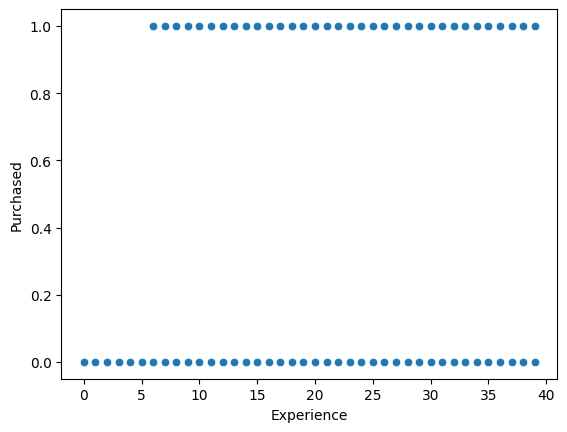

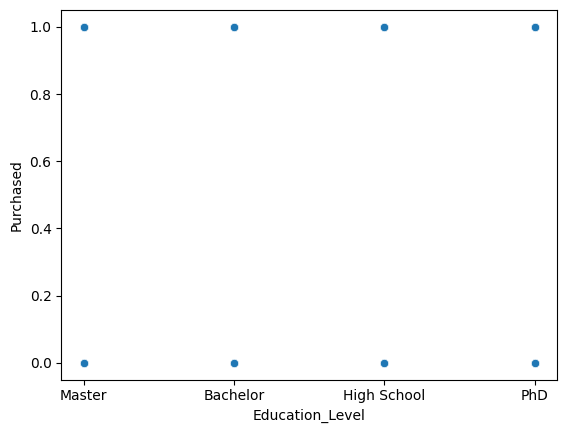

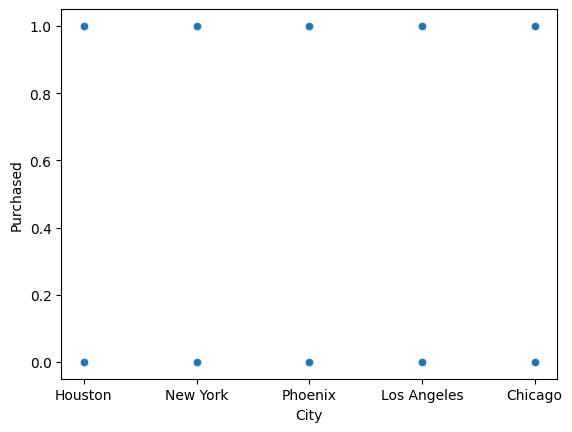

In [50]:
for i in x:
    sns.scatterplot(x=x[i],y='Purchased',data=df)
    plt.show()

In [51]:
# So, for models that treat numbers mathematically (like Linear Regression, Logistic Regression, SVM, KNN),
# label encoding can confuse the model and hurt performance.

from sklearn.preprocessing import OrdinalEncoder
oe=OrdinalEncoder(categories=[['High School','Bachelor','Master','PhD']])
x['Education_Level']=oe.fit_transform(x[['Education_Level']])

edu_encoded = pd.get_dummies(x['City'], drop_first=True).astype(int)

# 3 Merge with original DataFrame (remove old column)
x = pd.concat([x.drop('City', axis=1), edu_encoded], axis=1)
x

,Age,Salary,Experience,Education_Level,Houston,Los Angeles,New York,Phoenix
0,56,81272,9,2.0,1,0,0,0
1,46,112152,9,1.0,1,0,0,0
2,32,87649,12,0.0,0,0,1,0
3,60,84674,36,1.0,1,0,0,0
4,25,33760,37,1.0,0,0,0,1
...,...,...,...,...,...,...,...,...
1995,42,100098,17,3.0,0,0,0,0
1996,37,93016,25,2.0,0,1,0,0
1997,19,46672,6,3.0,0,0,0,0
1998,56,24213,0,3.0,0,0,0,1


In [56]:
df_dum=x.copy()
df_dum['Purchased']=y

<Axes: >

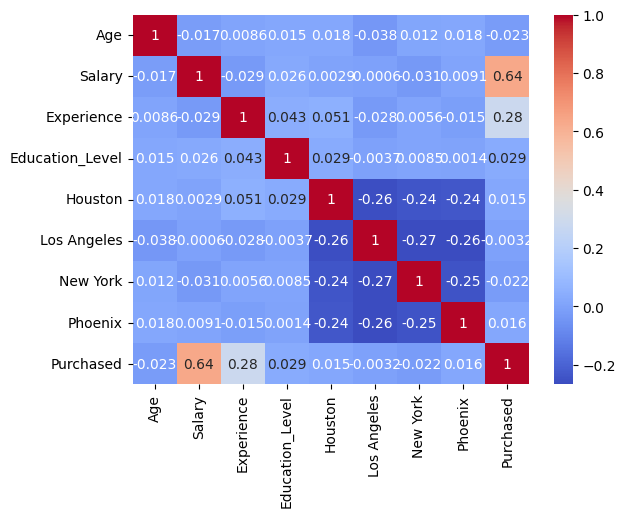

In [58]:
sns.heatmap(df_dum.corr(),annot=True,cmap='coolwarm')

In [59]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=42)
x_train.head()

,Age,Salary,Experience,Education_Level,Houston,Los Angeles,New York,Phoenix
836,46,82539,6,1.0,0,0,0,0
575,64,84041,36,3.0,0,0,1,0
557,47,30634,17,2.0,0,1,0,0
1235,55,92954,21,1.0,0,0,0,0
1360,44,98002,11,1.0,0,0,0,1


In [60]:
x_test.head()

,Age,Salary,Experience,Education_Level,Houston,Los Angeles,New York,Phoenix
1860,57,20159,38,3.0,1,0,0,0
353,35,49328,2,2.0,0,1,0,0
1333,60,87580,3,2.0,0,1,0,0
905,61,25105,14,1.0,0,0,0,0
1289,36,79711,8,2.0,0,0,0,0


In [61]:
y_train.head()

,Purchased
836,1
575,1
557,0
1235,1
1360,1


In [62]:
y_train.head()

,Purchased
836,1
575,1
557,0
1235,1
1360,1


In [64]:
from sklearn.tree import DecisionTreeClassifier
model=DecisionTreeClassifier(random_state=42)
model.fit(x_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [65]:
ypred=model.predict(x_test)
ypred

array([0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0,
       1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0,
       1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1,
       1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1,
       1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1,
       1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1,
       1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1,
       1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1,
       0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0,
       1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1,
       1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1,
       0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0,
       1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1,

In [66]:
res=pd.DataFrame(columns=['actual','predicted'])
res['actual']=y_test
res['predicted']=ypred
res.reset_index()
res.head()

,actual,predicted
1860,0,0
353,0,0
1333,0,0
905,0,0
1289,1,1


Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       262
           1       1.00      1.00      1.00       338

    accuracy                           1.00       600
   macro avg       1.00      1.00      1.00       600
weighted avg       1.00      1.00      1.00       600



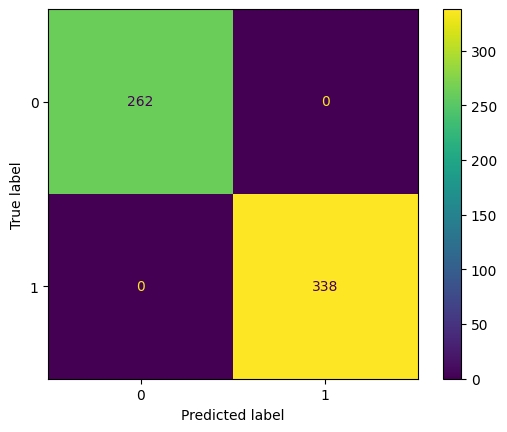

In [67]:
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, ypred))
print(classification_report(y_test, ypred))
ConfusionMatrixDisplay.from_estimator(model, x_test, y_test)
plt.show()